# K-invariance of microstate metrics
## MPILMBB EEG microstate sequences

**Aim:**
Compare microstate metrics that are expected to change mechanically with the number
of clusters *K* against metrics that should be comparatively **K-invariant** if they
capture a genuine property of the underlying continuous EEG dynamics rather than an
artifact of how finely that dynamics is partitioned into discrete states.

**Method:**
For each subject (n=201, `smoothing='b3'` EC recordings, the only smoothing level for
which K=4, 5, and 6 clustering results are locally available) we compute, at each of
`K in [4, 5, 6]`:

- **Duration** and **occurrence rate** (`mstsa.dur_occ_cov`): expected to change with
  *K* almost by construction -- adding more clusters subdivides the state space into
  smaller, shorter-lived regions, so mean dwell time should shrink and occurrence
  rate should rise as *K* increases.
- **Relaxation time** (`mstsa.relaxation_time`): the inverse spectral gap of the
  conditional transition matrix, `1 / (lambda_0 - lambda_1)`. This characterizes how
  quickly the *global* Markov-chain approximation of the sequence forgets its initial
  state -- a property of the process' overall temporal structure, not obviously tied
  to how many discrete symbols it is described with.
- **Normalized entropy rate** (`mstsa.entropy_rate`, fixed `kmax=5`): the raw entropy
  rate necessarily grows with *K* (more symbols -> more bits per symbol at maximum),
  so it is normalized by the maximum possible entropy `log2(K)` (the entropy of a
  uniform i.i.d. source over K symbols), giving a value in `[0, 1]` that is
  comparable across K if it reflects the same underlying relative predictability.
- **Normalized excess entropy** (the intercept `ee` already returned by
  `mstsa.entropy_rate`, divided by `log2(K)`): the "predictive information" of the
  sequence, i.e. how much knowing the past reduces uncertainty about the future
  beyond the entropy rate itself: same K-dependent scale issue and normalization
  rationale as entropy rate, obtained at no extra computational cost.
- **Hurst exponent** (`mstsa.dfa` on the raw symbolic sequence): a scale-free,
  dimensionless exponent characterizing long-range self-similarity. Unlike the other
  metrics here it needs no explicit normalization by K, making it a more direct test
  of K-invariance.
- **Normalized active information storage** (`mstsa.ais(x, K, k=1)`, divided by
  `log2(K)`): like entropy rate, AIS is bounded by `log2(K)`, so its raw value grows
  with K; the normalized version asks whether relative predictability from one step
  of history is K-invariant.
- **Normalized LZ76 complexity** (`mstsa.lz76`, divided by `log2(K)`): LZ76 already
  compensates for sequence length via its `log2(n)/n` term, but not for alphabet
  size, so the same log2(K) normalization used for entropy rate is applied here too;
  ties in with the LZ76-converges-to-entropy-rate argument used in
  `optimum-history-length.ipynb`.
- **Normalized entropy production** (`mstsa.detailed_balance`, Roldan-Parrondo
  statistic, divided by `log2(K)`): quantifies time-irreversibility of the
  transition structure (used in `Assessing non-Markovianity.ipynb`); normalizing
  tests whether the *degree* of broken detailed balance is a property of the
  dynamics or an artifact of K.
- **Spectral entropy of the transition-matrix eigenvalues** (Shannon entropy of the
  normalized eigenvalue magnitudes of `mstsa.tpm_cond`, divided by `log2(K)`): a
  generalization of relaxation time (which only uses the top spectral gap
  `lambda_0 - lambda_1`) to the whole eigenvalue spectrum, testing whether the full
  relaxation structure -- not just its slowest mode -- is K-invariant. Note this uses
  the *probability-weighted* transition matrix, not the 0/1 adjacency matrix of
  allowed transitions -- see the topological entropy metric below for why that
  distinction matters.
- **Normalized topological entropy** (`mstsa.topological_entropy(x, K, k=kmax_er)`,
  divided by `log2(K)`, new in `mstsa>=0.3.1`): counts the number of distinct
  length-`k` symbol blocks actually observed, `h_top(k) = log2(N(k)) / k`, the
  classical block-counting definition of topological entropy (Adler, Konheim &
  McAndrew, 1965). Unlike the spectral-entropy-of-T metric above, which is
  trivially pinned near its ceiling by Perron-Frobenius (T's leading eigenvalue is
  always 1), topological entropy only asks *which* transitions occur at all, not how
  often -- the correct classical analogue of the "0/1 adjacency matrix" invariant,
  and an upper bound on the metric (Shannon) entropy rate. Block length is fixed to
  `kmax_er` so it is computed over the same-size window as normalized entropy rate,
  for direct comparability.

Each metric is compared across `K=4,5,6` with a repeated-measures omnibus test
(Shapiro-Wilk-gated: RM-ANOVA if normal at every K, Friedman otherwise -- decided
once per metric, following the convention used in `01_microstate_parameters.ipynb`),
reporting an effect size (partial eta-squared or Kendall's W) alongside the p-value
since with n=201 subjects even tiny, practically unimportant differences reach very
small p-values.

Computation and plotting are kept in separate cells, and computation results are
cached to disk under `../data/cache/k_invariance/`, so that a plot-only edit does not
require re-running the (comparatively expensive) per-subject computations.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import shapiro, friedmanchisquare
from statsmodels.stats.anova import AnovaRM
import mstsa

print(f"mstsa version: {mstsa.__version__}")

mstsa version: 0.4.0


In [2]:
data_path = "../data/mpilmbb"
fs = 250              # Hz (4 ms / sample)
smoothing = 'b3'      # only smoothing level with K=4,5,6 all available locally
Ks = [4, 5, 6]

import glob
import re

subj_sets = {}
for K in Ks:
    pattern = f"{data_path}/*_EC_ms_{smoothing}_K{K}_ep00.npy"
    subj_sets[K] = set(re.match(r'(sub-\d+)_', os.path.basename(f)).group(1)
                        for f in glob.glob(pattern))
    print(f"K={K}: {len(subj_sets[K])} subjects")

subjects = sorted(set.intersection(*subj_sets.values()))
print(f"{len(subjects)} subjects with all of K={Ks} available")

K=4: 201 subjects
K=5: 201 subjects
K=6: 201 subjects
201 subjects with all of K=[4, 5, 6] available


## Compute metrics

For each subject and each *K*, load the corresponding `_EC_ms_b3_K{K}_ep00.npy`
sequence and compute the eleven metrics described above. Duration and occurrence are
averaged across the *K* microstates to give one value per subject (matching how the
other metrics are already single, sequence-level values).

In [3]:
kmax_er = 5
p_dfa = dict(lmin=20, lmax=3000, fitmin=20, fitmax=3000, nsteps=30)


def safe_dfa(x, **kwargs):
    """mstsa.dfa on a constant sequence divides by zero and returns NaN."""
    if np.all(x == x[0]):
        return 0.5
    return mstsa.dfa(x, **kwargs)


cache_dir = "../data/cache/k_invariance"
os.makedirs(cache_dir, exist_ok=True)
cache_file = os.path.join(cache_dir, f"metrics_v3_{smoothing}.npz")

metric_names = ['duration', 'occurrence', 'relaxation', 'er_norm', 'ee_norm',
                 'hurst', 'ais_norm', 'lzc_norm', 'entropy_production_norm',
                 'spectral_entropy', 'topo_ent_norm']

if os.path.exists(cache_file):
    d = np.load(cache_file)
    results = {K: {m: d[f"{m}_K{K}"] for m in metric_names} for K in Ks}
    print(f"loaded cached metrics from {cache_file}")
else:
    results = {K: {m: np.zeros(len(subjects)) for m in metric_names} for K in Ks}

    for K in Ks:
        log2K = np.log2(K)
        for i, subj in enumerate(subjects):
            fname = f"{data_path}/{subj}_EC_ms_{smoothing}_K{K}_ep00.npy"
            x = np.load(fname)

            dur_dict, occ, cov = mstsa.dur_occ_cov(x, fs=fs)
            all_durations = np.concatenate([dur_dict[k] for k in range(K)])
            results[K]['duration'][i] = all_durations.mean()
            results[K]['occurrence'][i] = occ.mean()

            results[K]['relaxation'][i] = mstsa.relaxation_time(x, K)

            er, ee = mstsa.entropy_rate(x, K, kmax=kmax_er)
            results[K]['er_norm'][i] = er / log2K
            results[K]['ee_norm'][i] = ee / log2K

            results[K]['hurst'][i] = safe_dfa(x.astype(np.float64), **p_dfa)

            results[K]['ais_norm'][i] = mstsa.ais(x, K, k=1) / log2K

            results[K]['lzc_norm'][i] = mstsa.lz76(x) / log2K

            t1_roldan, t2_lynn = mstsa.detailed_balance(x, K)
            results[K]['entropy_production_norm'][i] = t1_roldan / log2K

            T = mstsa.tpm_cond(x, K)
            eig_mags = np.abs(np.linalg.eigvals(T))
            eig_mags = eig_mags / eig_mags.sum()
            spec_ent = -np.sum(eig_mags * np.log2(eig_mags + 1e-300))
            results[K]['spectral_entropy'][i] = spec_ent / log2K

            results[K]['topo_ent_norm'][i] = mstsa.topological_entropy(x, K, k=kmax_er) / log2K

            print(f"K={K} [{i+1}/{len(subjects)}] {subj}", end="\r")
        print()

    print("done.")
    save_dict = {f"{m}_K{K}": results[K][m] for K in Ks for m in metric_names}
    np.savez(cache_file, **save_dict)

loaded cached metrics from ../data/cache/k_invariance/metrics_v3_b3.npz


## Repeated-measures comparison across K

Shapiro-Wilk decides once per metric between RM-ANOVA (if every K is normally
distributed) and the Friedman test (otherwise); effect size is partial eta-squared
for RM-ANOVA or Kendall's W for Friedman.

In [4]:
def sig_stars(p):
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'


def effect_label(w):
    if w < 0.1:
        return 'negligible'
    if w < 0.3:
        return 'small'
    if w < 0.5:
        return 'moderate'
    return 'large'


def compare_across_K(data_by_K, use_parametric):
    n = len(next(iter(data_by_K.values())))
    k = len(data_by_K)
    if use_parametric:
        df = pd.DataFrame({
            'subject': np.tile(np.arange(n), k),
            'condition': np.repeat(list(data_by_K.keys()), n),
            'value': np.concatenate(list(data_by_K.values())),
        })
        aov = AnovaRM(df, 'value', 'subject', within=['condition']).fit()
        stat = aov.anova_table['F Value'].iloc[0]
        p = aov.anova_table['Pr > F'].iloc[0]
        df1 = aov.anova_table['Num DF'].iloc[0]
        df2 = aov.anova_table['Den DF'].iloc[0]
        effect = (stat * df1) / (stat * df1 + df2)
        test = 'RM-ANOVA'
    else:
        stat, p = friedmanchisquare(*data_by_K.values())
        effect = stat / (n * (k - 1))  # Kendall's W
        test = 'Friedman'
    return dict(test=test, statistic=stat, pvalue=p, effect=effect)


alpha = 0.05
metric_labels = {
    'duration': 'Mean duration (ms)',
    'occurrence': 'Occurrence (events/s)',
    'relaxation': 'Relaxation time (samples)',
    'er_norm': 'Normalized entropy rate (h / log2 K)',
    'ee_norm': 'Normalized excess entropy (E / log2 K)',
    'hurst': 'Hurst exponent (DFA)',
    'ais_norm': 'Normalized AIS (k=1) (/ log2 K)',
    'lzc_norm': 'Normalized LZ76 (/ log2 K)',
    'entropy_production_norm': 'Normalized entropy production (/ log2 K)',
    'spectral_entropy': 'Spectral entropy of T eigenvalues (/ log2 K)',
    'topo_ent_norm': 'Normalized topological entropy (/ log2 K)',
}

stats_results = {}
for measure in metric_names:
    normal_measure = all(shapiro(results[K][measure]).pvalue > alpha for K in Ks)
    data_by_K = {K: results[K][measure] for K in Ks}
    res = compare_across_K(data_by_K, normal_measure)
    stats_results[measure] = res
    print(f"{metric_labels[measure]:>42s}: {res['test']:>9s}  stat={res['statistic']:.3f}  "
          f"p={res['pvalue']:.4g}  {sig_stars(res['pvalue'])}   "
          f"effect={res['effect']:.3f} ({effect_label(res['effect'])})")

                        Mean duration (ms):  Friedman  stat=351.075  p=5.823e-77  ***   effect=0.873 (large)
                     Occurrence (events/s):  Friedman  stat=400.010  p=1.377e-87  ***   effect=0.995 (large)
                 Relaxation time (samples):  Friedman  stat=180.090  p=7.835e-40  ***   effect=0.448 (moderate)
      Normalized entropy rate (h / log2 K):  Friedman  stat=386.279  p=1.32e-84  ***   effect=0.961 (large)
    Normalized excess entropy (E / log2 K):  Friedman  stat=208.279  p=5.928e-46  ***   effect=0.518 (large)
                      Hurst exponent (DFA):  Friedman  stat=184.786  p=7.485e-41  ***   effect=0.460 (moderate)
           Normalized AIS (k=1) (/ log2 K):  Friedman  stat=217.831  p=4.996e-48  ***   effect=0.542 (large)
                Normalized LZ76 (/ log2 K):  Friedman  stat=339.075  p=2.349e-74  ***   effect=0.843 (large)
  Normalized entropy production (/ log2 K):  Friedman  stat=185.682  p=4.784e-41  ***   effect=0.462 (moderate)
Spectral en

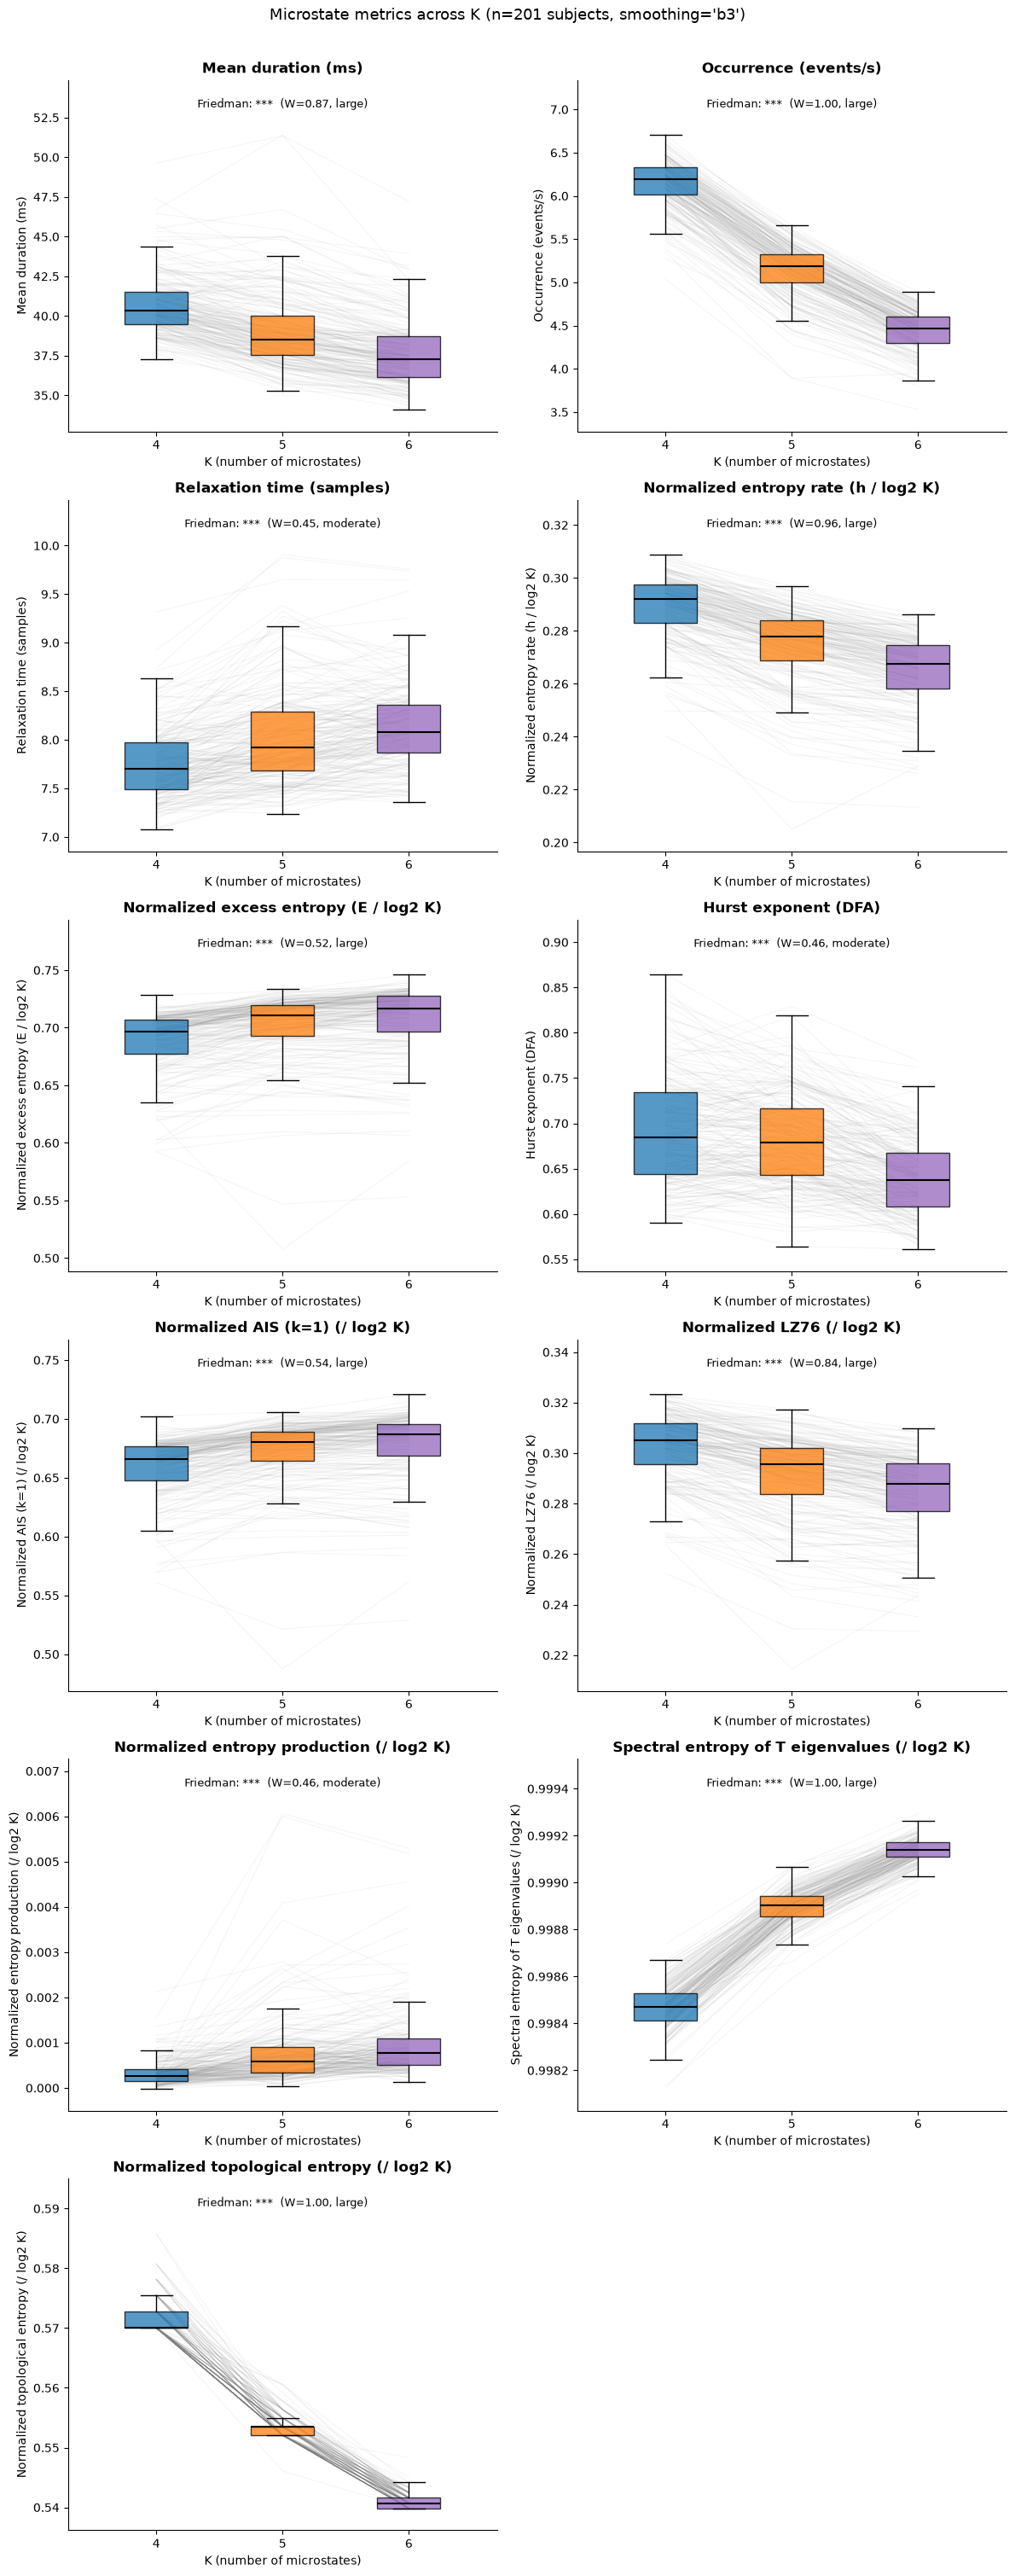

In [5]:
colors = {4: 'tab:blue', 5: 'tab:orange', 6: 'tab:purple'}

n_metrics = len(metric_names)
n_cols = 2
n_rows = -(-n_metrics // n_cols)  # ceil
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))

for ax, measure in zip(axes.flat, metric_names):
    data = np.stack([results[K][measure] for K in Ks], axis=1)  # (n_subjects, len(Ks))

    # spaghetti lines: each subject's value across K
    for row in data:
        ax.plot(Ks, row, color='gray', alpha=0.08, lw=0.8, zorder=1)

    bp = ax.boxplot([data[:, j] for j in range(len(Ks))], positions=Ks, widths=0.5,
                     patch_artist=True, showfliers=False, zorder=3,
                     medianprops=dict(color='black', linewidth=1.5))
    for patch, K in zip(bp['boxes'], Ks):
        patch.set_facecolor(colors[K])
        patch.set_alpha(0.75)

    res = stats_results[measure]
    ymax, ymin = data.max(), data.min()
    span = ymax - ymin
    ax.set_ylim(ymin - 0.08 * span, ymax + 0.20 * span)
    ax.annotate(f"{res['test']}: {sig_stars(res['pvalue'])}  "
                f"({'eta2' if res['test'] == 'RM-ANOVA' else 'W'}={res['effect']:.2f}, "
                f"{effect_label(res['effect'])})",
                (np.mean(Ks), ymax + 0.10 * span), ha='center', fontsize=9)

    ax.set_xticks(Ks)
    ax.set_xlim(Ks[0] - 0.7, Ks[-1] + 0.7)
    ax.set_xlabel('K (number of microstates)')
    ax.set_ylabel(metric_labels[measure])
    ax.set_title(metric_labels[measure], fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

for ax in axes.flat[n_metrics:]:
    ax.set_visible(False)

fig.suptitle(f'Microstate metrics across K (n={len(subjects)} subjects, smoothing={smoothing!r})',
             fontsize=13, y=1.005)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/k_invariance_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## Auto-information function (AIF), normalized to AIF(0)

`mstsa.aif` gives the time-lagged mutual information `I(X_t; X_{t+k})`, computed here
for the first 100 lags (`kmax=100`). `AIF(0) = H(X_t)`, the marginal entropy, which by
construction grows with *K* (more available symbols -> more entropy) -- so the raw
AIF curves are not directly comparable across K. Dividing each subject's curve by its
own `AIF(0)` removes this trivial scale difference and isolates the *shape* of the
memory decay: if the normalized curves overlap across K=4,5,6, the temporal profile
of information decay is K-invariant even though the absolute information content is
not.

AIF is far more expensive than the other measures in this notebook (~4.5 s per call
at `kmax=100`), so -- following the same approach used in
`Assessing non-Markovianity.ipynb` -- we use a random subset of `n_subset=30`
subjects (fixed seed) rather than the full n=201 cohort.

In [6]:
kmax_aif = 100
n_subset = 30

cache_file_aif = os.path.join(cache_dir, f"aif_{smoothing}_n{n_subset}.npz")

if os.path.exists(cache_file_aif):
    d = np.load(cache_file_aif)
    aif_subset_idx = d['subset_idx']
    aif_norm = {K: d[f"aif_norm_K{K}"] for K in Ks}
    print(f"loaded cached AIF results from {cache_file_aif}")
else:
    rng = np.random.default_rng(0)
    aif_subset_idx = rng.choice(len(subjects), size=n_subset, replace=False)
    aif_subset = [subjects[i] for i in aif_subset_idx]

    aif_norm = {K: np.zeros((n_subset, kmax_aif)) for K in Ks}

    for K in Ks:
        for i, subj in enumerate(aif_subset):
            fname = f"{data_path}/{subj}_EC_ms_{smoothing}_K{K}_ep00.npy"
            x = np.load(fname)
            aif_vals = mstsa.aif(x, K, kmax=kmax_aif)
            aif_norm[K][i] = aif_vals / aif_vals[0]
            print(f"K={K} [{i+1}/{n_subset}] {subj}", end="\r")
        print()

    print("done.")
    save_dict = {'subset_idx': aif_subset_idx}
    save_dict.update({f"aif_norm_K{K}": aif_norm[K] for K in Ks})
    np.savez(cache_file_aif, **save_dict)

lags_aif = np.arange(kmax_aif)

loaded cached AIF results from ../data/cache/k_invariance/aif_b3_n30.npz


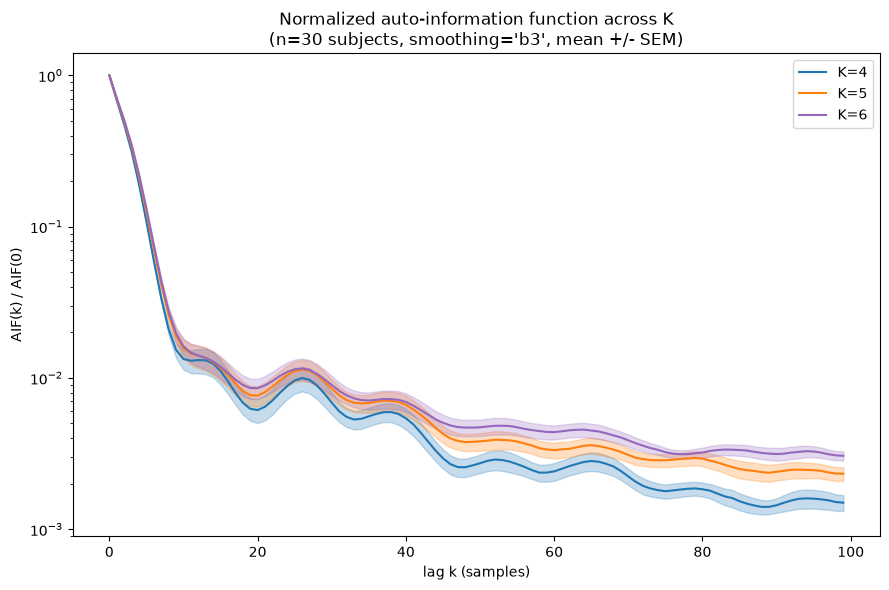

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))

for K in Ks:
    mean_curve = aif_norm[K].mean(axis=0)
    sem_curve = aif_norm[K].std(axis=0, ddof=1) / np.sqrt(n_subset)
    ax.plot(lags_aif, mean_curve, color=colors[K], lw=1.5, label=f'K={K}')
    ax.fill_between(lags_aif, mean_curve - sem_curve, mean_curve + sem_curve,
                     color=colors[K], alpha=0.25)

ax.set_yscale('log')
ax.set_xlabel('lag k (samples)')
ax.set_ylabel('AIF(k) / AIF(0)')
ax.set_title(f'Normalized auto-information function across K\n'
             f'(n={n_subset} subjects, smoothing={smoothing!r}, mean +/- SEM)')
ax.legend()
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/k_invariance_aif.png', dpi=150, bbox_inches='tight')
plt.show()

## Partial auto-information function (PAIF), normalized to PAIF(0)

`mstsa.paif` gives the partial auto-information function for the first 7 lags
(`kmax=7`); `PAIF(0)` equals the marginal entropy `H(X_t)`, same as `AIF(0)`, and
grows with *K* for the same reason, so each subject's curve is again normalized by
its own `PAIF(0)`. Unlike AIF, PAIF is cheap (<0.1 s/call), so this uses the full
n=201 cohort rather than a subset.

In [8]:
kmax_paif = 7

cache_file_paif = os.path.join(cache_dir, f"paif_{smoothing}.npz")

if os.path.exists(cache_file_paif):
    d = np.load(cache_file_paif)
    paif_norm = {K: d[f"paif_norm_K{K}"] for K in Ks}
    print(f"loaded cached PAIF results from {cache_file_paif}")
else:
    paif_norm = {K: np.zeros((len(subjects), kmax_paif)) for K in Ks}

    for K in Ks:
        for i, subj in enumerate(subjects):
            fname = f"{data_path}/{subj}_EC_ms_{smoothing}_K{K}_ep00.npy"
            x = np.load(fname)
            paif_vals = mstsa.paif(x, K, kmax=kmax_paif)
            paif_norm[K][i] = paif_vals / paif_vals[0]
            print(f"K={K} [{i+1}/{len(subjects)}] {subj}", end="\r")
        print()

    print("done.")
    save_dict = {f"paif_norm_K{K}": paif_norm[K] for K in Ks}
    np.savez(cache_file_paif, **save_dict)

lags_paif = np.arange(kmax_paif)

loaded cached PAIF results from ../data/cache/k_invariance/paif_b3.npz


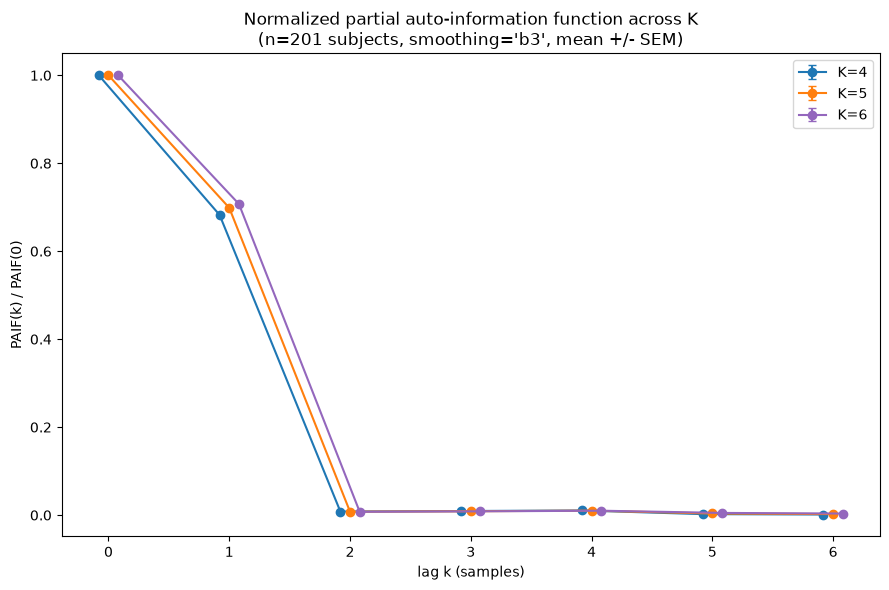

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))

offsets = {4: -0.08, 5: 0.0, 6: 0.08}
for K in Ks:
    mean_curve = paif_norm[K].mean(axis=0)
    sem_curve = paif_norm[K].std(axis=0, ddof=1) / np.sqrt(len(subjects))
    ax.errorbar(lags_paif + offsets[K], mean_curve, yerr=sem_curve, fmt='-o',
                color=colors[K], capsize=3, label=f'K={K}')

ax.set_xlabel('lag k (samples)')
ax.set_ylabel('PAIF(k) / PAIF(0)')
ax.set_xticks(lags_paif)
ax.set_title(f'Normalized partial auto-information function across K\n'
             f'(n={len(subjects)} subjects, smoothing={smoothing!r}, mean +/- SEM)')
ax.legend()
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/k_invariance_paif.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary: relative K-sensitivity

For each subject and metric, the coefficient of variation across `K=4,5,6`
(`CV = std / mean`, using the absolute mean to keep CV positive for signed metrics)
quantifies how much that metric moves *within a subject* purely as a function of K.
A metric that is truly K-invariant should have CV close to 0; duration and
occurrence, expected to scale mechanically with K, serve as the "positive control"
against which the other metrics are judged.

Note that most of the repeated-measures tests above are "large" effects (Kendall's
W > 0.8) regardless of the metric -- with n=201 subjects, the omnibus test has very
high power to detect *any* consistent monotonic trend across K, so W measures how
reliably a metric moves in the same direction across subjects, not how much it
moves. CV is the more informative quantity for judging practical K-sensitivity.
Sorted from most to least K-invariant (`figures/k_invariance_summary.png`):

1. **Spectral entropy of T eigenvalues (CV=0.000)** -- but this is a **ceiling
   artifact**, not a real finding: the raw values sit at 0.998-0.999 for every K
   (see the printed means above), meaning normalized eigenvalue-magnitude entropy is
   essentially saturated at its maximum regardless of the transition matrix's actual
   structure. Weighting eigenvalues by `|lambda|/sum(|lambda|)` and computing entropy
   on that distribution is too crude a summary of the spectrum -- it doesn't
   distinguish informative structure from noise here, so this metric should be
   considered uninformative in this form rather than "the most K-invariant metric".
2. **Normalized excess entropy (CV=0.015)** and **normalized AIS at k=1
   (CV=0.016)**: the two best *genuine* K-invariant metrics found here, both clearly
   ahead of relaxation time.
3. **Relaxation time (CV=0.026)** and **normalized LZ76 (CV=0.028)**: also
   comparatively stable, consistent with the earlier (four-metric) result.
4. **Mean duration (CV=0.035)**, **normalized entropy rate (CV=0.038)**, and the
   **Hurst exponent (CV=0.041)**: a middle tier, all modestly K-sensitive despite
   large Friedman effects -- the Hurst exponent in particular does *not* show the
   invariance advantage one might expect from a scale-free exponent that needs no
   explicit normalization.
5. **Occurrence rate (CV=0.134)**: K-sensitive as expected.
6. **Normalized entropy production (CV=0.474)**: by far the *least* invariant metric
   -- but partly another artifact rather than a clean result: its raw mean is close
   to zero (~0.0003-0.001 bits/sample) and *also* roughly triples from K=4 to K=6, so
   a small-denominator effect inflates CV on top of a real, substantial K-dependence
   in the numerator. Entropy production should not be treated as K-invariant.

Net picture: normalized excess entropy and normalized AIS are the standout
K-invariant candidates from this comparison; relaxation time and normalized LZ76
also hold up reasonably well. The two metrics that superficially look "most
invariant" or "most sensitive" (spectral entropy, entropy production) turn out to be
measurement artifacts on closer inspection, illustrating why raw CV rankings need to
be checked against the underlying values before drawing conclusions.

In [10]:
cv_by_metric = {}
for measure in metric_names:
    data = np.stack([results[K][measure] for K in Ks], axis=1)  # (n_subjects, len(Ks))
    cv = data.std(axis=1) / np.abs(data.mean(axis=1))
    cv_by_metric[measure] = cv
    print(f"{metric_labels[measure]:>42s}: mean CV = {cv.mean():.3f}  (median {np.median(cv):.3f})")

                        Mean duration (ms): mean CV = 0.035  (median 0.035)
                     Occurrence (events/s): mean CV = 0.134  (median 0.133)
                 Relaxation time (samples): mean CV = 0.026  (median 0.024)
      Normalized entropy rate (h / log2 K): mean CV = 0.038  (median 0.036)
    Normalized excess entropy (E / log2 K): mean CV = 0.015  (median 0.014)
                      Hurst exponent (DFA): mean CV = 0.041  (median 0.040)
           Normalized AIS (k=1) (/ log2 K): mean CV = 0.016  (median 0.015)
                Normalized LZ76 (/ log2 K): mean CV = 0.028  (median 0.026)
  Normalized entropy production (/ log2 K): mean CV = 0.474  (median 0.482)
Spectral entropy of T eigenvalues (/ log2 K): mean CV = 0.000  (median 0.000)
 Normalized topological entropy (/ log2 K): mean CV = 0.023  (median 0.022)


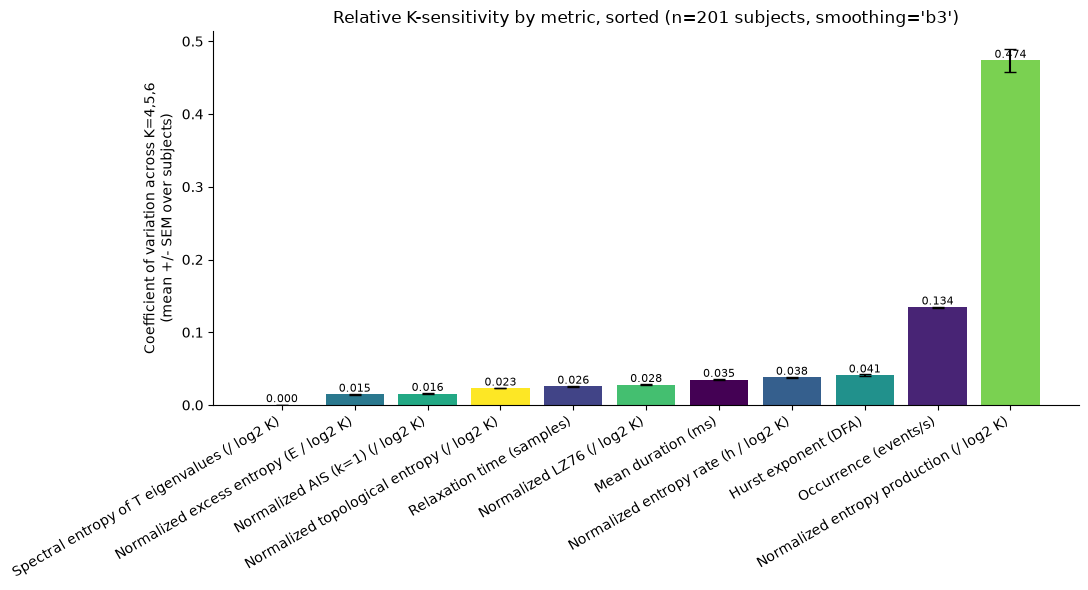

In [11]:
fig, ax = plt.subplots(figsize=(11, 6))
bar_colors = plt.cm.viridis(np.linspace(0, 1, len(metric_names)))
means = [cv_by_metric[m].mean() for m in metric_names]
sems = [cv_by_metric[m].std(ddof=1) / np.sqrt(len(subjects)) for m in metric_names]

# sort by mean CV so the ranking is easy to read
order = np.argsort(means)
sorted_names = [metric_names[i] for i in order]
sorted_means = [means[i] for i in order]
sorted_sems = [sems[i] for i in order]
sorted_colors = bar_colors[order]

ax.bar(range(len(sorted_names)), sorted_means, yerr=sorted_sems, capsize=4, color=sorted_colors)
ax.set_xticks(range(len(sorted_names)))
ax.set_xticklabels([metric_labels[m] for m in sorted_names], rotation=30, ha='right')
ax.set_ylabel('Coefficient of variation across K=4,5,6\n(mean +/- SEM over subjects)')
ax.set_title(f'Relative K-sensitivity by metric, sorted (n={len(subjects)} subjects, smoothing={smoothing!r})')
for x, m_val in zip(range(len(sorted_names)), sorted_means):
    ax.annotate(f"{m_val:.3f}", (x, m_val), ha='center', va='bottom', fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/k_invariance_summary.png', dpi=150, bbox_inches='tight')
plt.show()